In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

In [2]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

,n_components,3
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,10
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [5]:
print(gm.weights_)
print(gm.means_)
print("")
print(gm.covariances_)

[0.33333333 0.33333333 0.33333333]
[[-2.60842567  9.03771305]
 [-6.88302287 -6.96320924]
 [ 4.72565847  2.00310936]]

[[[ 0.47916216  0.02795775]
  [ 0.02795775  0.63177738]]

 [[ 0.65895602  0.06127387]
  [ 0.06127387  0.62897448]]

 [[ 0.68501509 -0.0630035 ]
  [-0.0630035   0.54402201]]]


In [6]:
gm.converged_

True

In [7]:
gm.n_iter_

2

In [12]:
gm.score_samples(X).round(2)

array([ -2.85,  -2.87,  -3.8 ,  -3.12,  -4.76,  -2.71,  -2.45,  -2.68,
        -2.44,  -3.34,  -4.23,  -2.76,  -4.46,  -3.52,  -2.75,  -2.61,
        -3.82,  -4.56,  -2.81,  -4.96,  -3.87,  -2.41,  -2.8 ,  -2.5 ,
        -2.53,  -3.78,  -3.08,  -5.14,  -2.98,  -3.05,  -2.99,  -3.07,
        -3.18,  -3.27,  -4.93,  -3.22,  -3.18,  -2.61,  -2.93,  -4.52,
        -3.31,  -2.44,  -2.65,  -3.29,  -3.08,  -3.61,  -2.57,  -2.6 ,
        -2.61,  -4.23,  -2.74,  -3.78,  -2.95,  -4.26,  -3.17, -11.34,
        -2.63,  -3.18,  -2.67,  -2.97,  -2.89,  -6.29,  -2.8 ,  -7.56,
        -3.14,  -2.99,  -2.82,  -3.35,  -3.92,  -3.05,  -3.11,  -4.62,
        -2.8 ,  -2.59,  -3.49,  -2.53,  -4.58,  -2.79,  -2.53,  -3.07,
        -2.92,  -2.82,  -3.05,  -2.91,  -2.94,  -3.46,  -3.19,  -5.04,
        -3.88,  -3.79,  -4.17,  -3.53,  -2.68,  -3.09,  -2.58,  -3.2 ,
        -3.04,  -2.71,  -4.14,  -4.51,  -2.93,  -2.62,  -2.67,  -3.4 ,
        -2.72,  -4.39,  -4.17,  -2.48,  -4.62,  -3.76,  -4.11,  -2.68,
      

C:\Users\User\AppData\Local\Temp\ipykernel_39456\4140162482.py:12: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  np.random.multivariate_normal(m, c, 300)


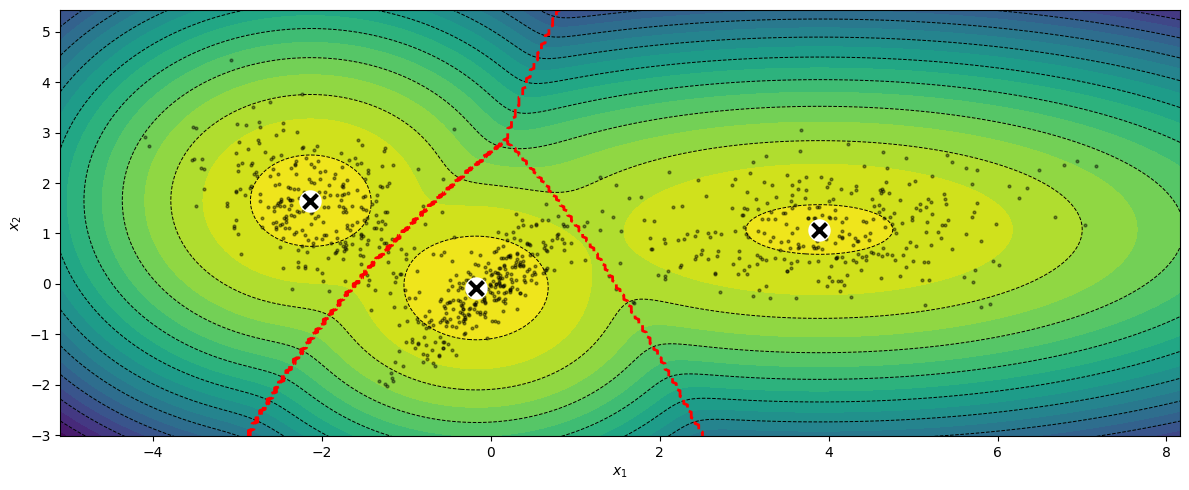

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# Sample data with 3 components
np.random.seed(42)
means = [[-2, 1.5], [0, 0], [4, 1]]
covs = [[[0.5, -0.3], [-0.3, 0.8]],
        [[0.2,  0.4], [ 0.4, 0.6]],
        [[1.5,  0.3], [ 0.3, 0.5]]]
X = np.vstack([
    np.random.multivariate_normal(m, c, 300)
    for m, c in zip(means, covs)
])

gm = GaussianMixture(n_components=3, n_init=10, random_state=42, covariance_type="diag")
gm.fit(X)

# Mesh grid
x1, x2 = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300))
grid = np.c_[x1.ravel(), x2.ravel()]

# Density (log-probability) and decision regions
density = gm.score_samples(grid).reshape(x1.shape)
regions = gm.predict(grid).reshape(x1.shape)

fig, ax = plt.subplots(figsize=(12, 5))

# Background density
ax.contourf(x1, x2, density, levels=20, cmap="viridis")
# Density contour lines
ax.contour(x1, x2, density, levels=10, colors="k", linewidths=0.7)
# Decision boundary (red dashed)
ax.contour(x1, x2, regions, levels=[0.5, 1.5], colors="red",
           linestyles="dashed", linewidths=2)

# Data points
ax.scatter(X[:,0], X[:,1], s=4, color="k", alpha=0.4)

# Cluster means (circled X)
ax.scatter(gm.means_[:,0], gm.means_[:,1],
           marker="o", s=200, facecolors="white", edgecolors="white", linewidths=2)
ax.scatter(gm.means_[:,0], gm.means_[:,1],
           marker="x", s=100, linewidths=3, color="black")

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.tight_layout()
plt.show()

In [15]:
print(gm.bic(X))

5981.293752031542


In [ ]:
from sklearn.mixture import BayesianGaussianMixture
bgm = BayesianGaussianMixture(n_components=10, n_init=10, max_iter=500, random_state=42)